In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix, classification_report, precision_recall_curve, roc_curve, brier_score_loss
from sklearn.calibration import CalibratedClassifierCV
import xgboost as xgb
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTEENN
import shap
import random
import warnings
warnings.filterwarnings('ignore')
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

In [2]:
train = pd.read_csv("GiveMeSomeCredit/cs-training.csv")
train.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,30588,0,0.003032,53,0,5.967504,8000.0,60,0,60,0,0.0
1,104199,0,0.010846,60,0,1.041757,70000.0,38,0,32,0,0.0
2,65729,1,0.036942,43,0,0.719174,55966.0,41,0,29,0,0.0
3,18260,0,0.635363,61,6,0.429449,48000.0,33,1,26,0,1.0
4,68910,0,0.297748,44,0,1.237481,12400.0,42,0,25,0,2.0


In [3]:
train.drop('Unnamed: 0', axis=1, inplace=True)
train.shape #Dimensions of data

(150000, 11)

In [4]:
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,0,0.003032,53,0,5.967504,8000.0,60,0,60,0,0.0
1,0,0.010846,60,0,1.041757,70000.0,38,0,32,0,0.0
2,1,0.036942,43,0,0.719174,55966.0,41,0,29,0,0.0
3,0,0.635363,61,6,0.429449,48000.0,33,1,26,0,1.0
4,0,0.297748,44,0,1.237481,12400.0,42,0,25,0,2.0


In [5]:
train.columns

Index(['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age',
       'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome',
       'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate',
       'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse',
       'NumberOfDependents'],
      dtype='object')

In [6]:
train.duplicated().value_counts()

False    149391
True        609
Name: count, dtype: int64

In [7]:
#Deleting the duplicate records
train.drop_duplicates(inplace = True)
# for null values and data types of each column
train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 149391 entries, 0 to 149999
Data columns (total 11 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   SeriousDlqin2yrs                      149391 non-null  int64  
 1   RevolvingUtilizationOfUnsecuredLines  149391 non-null  float64
 2   age                                   149391 non-null  int64  
 3   NumberOfTime30-59DaysPastDueNotWorse  149391 non-null  int64  
 4   DebtRatio                             149391 non-null  float64
 5   MonthlyIncome                         120170 non-null  float64
 6   NumberOfOpenCreditLinesAndLoans       149391 non-null  int64  
 7   NumberOfTimes90DaysLate               149391 non-null  int64  
 8   NumberRealEstateLoansOrLines          149391 non-null  int64  
 9   NumberOfTime60-89DaysPastDueNotWorse  149391 non-null  int64  
 10  NumberOfDependents                    145563 non-null  float64
dtypes: fl

In [8]:
# missing value percentage using function
def findMissPerc(df):
    return round(((df.isnull().sum()/df.shape[0])*100),2)
findMissPerc(train)

SeriousDlqin2yrs                         0.00
RevolvingUtilizationOfUnsecuredLines     0.00
age                                      0.00
NumberOfTime30-59DaysPastDueNotWorse     0.00
DebtRatio                                0.00
MonthlyIncome                           19.56
NumberOfOpenCreditLinesAndLoans          0.00
NumberOfTimes90DaysLate                  0.00
NumberRealEstateLoansOrLines             0.00
NumberOfTime60-89DaysPastDueNotWorse     0.00
NumberOfDependents                       2.56
dtype: float64

#### Null values are only in 2 columns - MonthlyIncome & NumberOfDependents

### Null value treatment for Number of Dependents
#### Possible problems
- ~3% missing values.
- Negative values (invalid).
- Extreme values (e.g., >20 → unlikely).

In [9]:
(train['NumberOfDependents'].isnull()).value_counts()

NumberOfDependents
False    145563
True       3828
Name: count, dtype: int64

In [10]:
train['NumberOfDependents'].describe()

count    145563.000000
mean          0.759863
std           1.116141
min           0.000000
25%           0.000000
50%           0.000000
75%           1.000000
max          20.000000
Name: NumberOfDependents, dtype: float64

#### No negative or extreme values here. Handling null values

In [11]:
train.groupby(['NumberOfDependents']).size()

NumberOfDependents
0.0     86392
1.0     26314
2.0     19521
3.0      9483
4.0      2862
5.0       746
6.0       158
7.0        51
8.0        24
9.0         5
10.0        5
13.0        1
20.0        1
dtype: int64

In [12]:
# for this integer variable , median and mode both are '0', hence substituting the same in null values.
train['NumberOfDependents'].fillna(0, inplace=True)

In [13]:
(train['NumberOfDependents'].isnull()).value_counts()

NumberOfDependents
False    149391
Name: count, dtype: int64

### Treatment for Monthly Income including null value treatment
#### Possible problems
- ~20% missing values(from above)
- Negative values (invalid).
- Zero values of monthly income are not impossible per se, but for them Debt Ratio will become infinite, which may become problematics while dealing with Debt Ratio column later.
    - As Debt Ratio = Monthly debt payments, alimony,living costs divided by monthy gross income
- Huge outliers (e.g., >1M).

In [14]:
(train['MonthlyIncome'].isnull()).value_counts()

MonthlyIncome
False    120170
True      29221
Name: count, dtype: int64

**29221 - rows does not have any monthly income value**

In [15]:
print(train['MonthlyIncome'].describe().apply(lambda x: f"{x:.2f}"))

count     120170.00
mean        6675.10
std        14389.58
min            0.00
25%         3400.00
50%         5400.00
75%         8250.00
max      3008750.00
Name: MonthlyIncome, dtype: object


#### No negative values here, handling null values, and capping extreme high incomes

In [16]:
((train['MonthlyIncome'].isnull()) | (train['MonthlyIncome']==0)).value_counts()

MonthlyIncome
False    118554
True      30837
Name: count, dtype: int64

In [17]:
(train['MonthlyIncome']==0).value_counts()

MonthlyIncome
False    147775
True       1616
Name: count, dtype: int64

As of now, there are only 1616 rows with '0' monthly income out of '120170' non null monthly income rows. Leaving them for now and deaing with them later along with Debt Ratio if needed. Focusing on null monthly income rows.

#### Imputing & respective Debt Ratio update
We will be imputing missing income with the median income of people in the same age group + number of dependents. Because both age and dependents strongly relate to income distribution as older people usually earn more, larger families may imply higher income of bread winner.<br>
For rows where MonthlyIncome was originally null, the DebtRatio will be adjusted because:-
- Original DebtRatio may have been computed using Debt / Income.
- If Income was missing (NaN), the ratio could be meaningless.<br>

After imputing MonthlyIncome, we recompute DebtRatio, it ensures that DebtRatio is consistent with the new imputed income values.
#### Capping extreme outliers
Clip income at 99th percentile (~40,000–50,000), because few million-dollar outliers distort models.

In [18]:
train['AgeGroup'] = pd.cut(train['age'], 
                        bins=[20, 30, 40, 50, 60, 70, 80, 100], 
                        labels=['20s', '30s', '40s', '50s', '60s', '70s', '80+'])

In [19]:
train[['age','AgeGroup']]

,age,AgeGroup
0,53,50s
1,60,50s
2,43,40s
3,61,60s
4,44,40s
...,...,...
149994,49,40s
149995,28,20s
149996,62,60s
149998,50,40s


In [20]:
group_median_income = train.groupby(['AgeGroup', 'NumberOfDependents'])['MonthlyIncome'].median()
pd.set_option('display.max_rows', None)# to display all values
print(group_median_income)
pd.reset_option("display.max_rows")# to do back to default

AgeGroup  NumberOfDependents
20s       0.0                    2596.0
          1.0                    3300.0
          2.0                    3500.0
          3.0                    4000.0
          4.0                    3390.0
          5.0                    4017.0
          6.0                    2070.0
          7.0                    8323.0
          8.0                       NaN
          9.0                       NaN
          10.0                      NaN
          13.0                      NaN
          20.0                      NaN
30s       0.0                    4430.0
          1.0                    4958.0
          2.0                    5314.0
          3.0                    5500.0
          4.0                    5697.0
          5.0                    6423.0
          6.0                    6539.0
          7.0                    6536.0
          8.0                    6375.0
          9.0                    3044.5
          10.0                   4833.0
          1

In [21]:
#Impute function
def impute_income(row):
    if pd.isna(row['MonthlyIncome']):
        try:
            val = group_median_income.loc[row['AgeGroup'], row['NumberOfDependents']]
            # If the group median itself is NaN, use global median
            if pd.isna(val):
                return train['MonthlyIncome'].median()
            else:
                return val
        except KeyError:
            # Fallback: group not found
            return train['MonthlyIncome'].median()
    else:
        return row['MonthlyIncome']

In [22]:
has_monthly_income_na = train['MonthlyIncome'].isna() #Seperately saving null monthly income rows
train['MonthlyIncome'] = train.apply(impute_income, axis=1) #Imputing as per above function

In [23]:
train.drop('AgeGroup', axis=1, inplace=True)
train['MonthlyIncome'].isnull().value_counts()

MonthlyIncome
False    149391
Name: count, dtype: int64

#### No more null values in Monthly income

In [24]:
# Cap income at 99th percentile to reduce the effect of extreme outliers.(CLipping/Winsorization)
income_cap = train['MonthlyIncome'].quantile(0.99)
train['MonthlyIncome'] = train['MonthlyIncome'].clip(upper=income_cap)

In [25]:
findMissPerc(train)

SeriousDlqin2yrs                        0.0
RevolvingUtilizationOfUnsecuredLines    0.0
age                                     0.0
NumberOfTime30-59DaysPastDueNotWorse    0.0
DebtRatio                               0.0
MonthlyIncome                           0.0
NumberOfOpenCreditLinesAndLoans         0.0
NumberOfTimes90DaysLate                 0.0
NumberRealEstateLoansOrLines            0.0
NumberOfTime60-89DaysPastDueNotWorse    0.0
NumberOfDependents                      0.0
dtype: float64

### No more null values

In [26]:
print(f"\033[1mTotal Records:-\033[0m\n{train.shape[0]}")
print(f"\n\033[1mCount of defaulters:-\033[0m\n{train['SeriousDlqin2yrs'].value_counts()}")
print(f"\n\033[1mPercent of defaulters:-\033[0m\n{train['SeriousDlqin2yrs'].value_counts(normalize = True)*100}")

Total Records:-
149391

Count of defaulters:-
SeriousDlqin2yrs
0    139382
1     10009
Name: count, dtype: int64

Percent of defaulters:-
SeriousDlqin2yrs
0    93.300132
1     6.699868
Name: proportion, dtype: float64


## Rearranging columns and performing individual variable analysis

In [27]:
train = train.reindex(columns=['SeriousDlqin2yrs','RevolvingUtilizationOfUnsecuredLines',
                                             'NumberOfOpenCreditLinesAndLoans','NumberRealEstateLoansOrLines',
                                             'age','DebtRatio','NumberOfTime30-59DaysPastDueNotWorse',
                                             'NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate',
                                             'MonthlyIncome','NumberOfDependents'])

In [28]:
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,age,DebtRatio,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome,NumberOfDependents
0,0,0.003032,60,60,53,5.967504,0,0,0,8000.0,0.0
1,0,0.010846,38,32,60,1.041757,0,0,0,23084.0,0.0
2,1,0.036942,41,29,43,0.719174,0,0,0,23084.0,0.0
3,0,0.635363,33,26,61,0.429449,6,0,1,23084.0,1.0
4,0,0.297748,42,25,44,1.237481,0,0,0,12400.0,2.0


### Column 1 -RevolvingUtilizationOfUnsecuredLines
Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits.
#### Possible Problems:
- Negative values (not possible).
- Values >1 (possible, but extreme → over-limit borrowing).
- Extreme outliers (e.g., >10).

In [29]:
train['RevolvingUtilizationOfUnsecuredLines'].describe()

count    149391.000000
mean          6.071087
std         250.263672
min           0.000000
25%           0.030132
50%           0.154235
75%           0.556494
max       50708.000000
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64

#### Clearly, there's no negative value and most values are less than 1, but the maximum values shows anomaly. Delving further

In [30]:
print(train['RevolvingUtilizationOfUnsecuredLines'].quantile([.9]))
print(train['RevolvingUtilizationOfUnsecuredLines'].quantile([.97]))

0.9    0.978007
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64
0.97    1.0
Name: RevolvingUtilizationOfUnsecuredLines, dtype: float64


#### We can see 97% values are less than 1 in column 'RevolvingUtilizationOfUnsecuredLines'. But can we delete all other values(that are greater than 1), are they insignificant?

In [31]:
(train[train['RevolvingUtilizationOfUnsecuredLines']>1]).groupby('SeriousDlqin2yrs').size()

SeriousDlqin2yrs
0    2084
1    1237
dtype: int64

#### Hence there are still many significant rows which contribute to deault, further checking for greater than 10

In [32]:
(train[train['RevolvingUtilizationOfUnsecuredLines']>10]).groupby('SeriousDlqin2yrs').size()

SeriousDlqin2yrs
0    224
1     17
dtype: int64

#### These values are not much sigificant(as these are very less number of records), hence dropping them

In [33]:
train.drop(train[train['RevolvingUtilizationOfUnsecuredLines'] > 10].index, inplace = True)
print(f"\033[1mTotal Records:-\033[0m\n{train.shape[0]}")

Total Records:-
149150


### Column 2 - NumberOfOpenCreditLinesAndLoans
Number of Open loans (installment like car loan or mortgage) and Lines of credit (e.g. credit cards)
#### Possible Problems:
- Negative values.
- Very high values (e.g., 100+ credit lines).

In [34]:
train['NumberOfOpenCreditLinesAndLoans'].describe()

count    149150.000000
mean          8.485297
std           5.138114
min           0.000000
25%           5.000000
50%           8.000000
75%          11.000000
max          60.000000
Name: NumberOfOpenCreditLinesAndLoans, dtype: float64

#### No negative values here, creating a histogram for better understanding

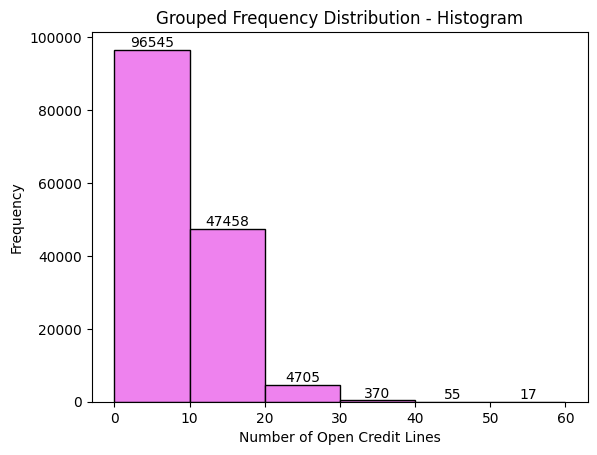

In [35]:
counts, bins, patches = plt.hist(train['NumberOfOpenCreditLinesAndLoans'], bins=6, edgecolor='black', color='violet')#the main graph

# Add frequency labels on top of bars
for count, patch in zip(counts, patches):
    plt.text(patch.get_x() + patch.get_width() / 2, count, int(count),
             ha='center', va='bottom')

plt.xlabel('Number of Open Credit Lines')
plt.ylabel('Frequency')
plt.title('Grouped Frequency Distribution - Histogram')
plt.show()

#### Seems not much problem with this variable, moving on to next column

### Column 3 - NumberRealEstateLoansOrLines
Number of mortgage and real estate loans including home equity lines of credit
#### Possible Problems:
- Negative values.
- Very large numbers (e.g., >50 mortgages unlikely).

In [36]:
train['NumberRealEstateLoansOrLines'].describe()

count    149150.000000
mean          1.022166
std           1.132271
min           0.000000
25%           0.000000
50%           1.000000
75%           2.000000
max          60.000000
Name: NumberRealEstateLoansOrLines, dtype: float64

#### No negative values here, but some records have very high value. Creating a histogram for better understanding

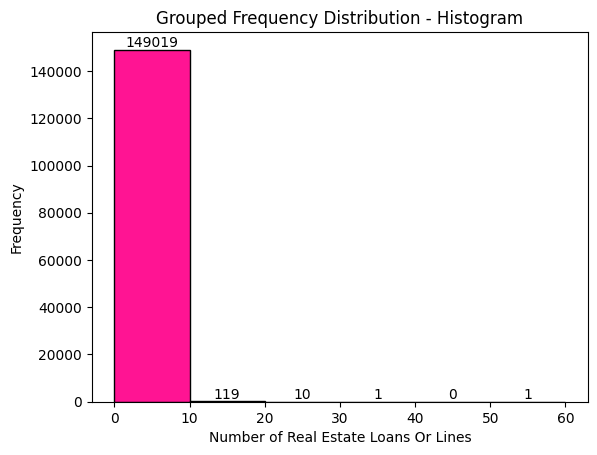

In [37]:
counts, bins, patches = plt.hist(train['NumberRealEstateLoansOrLines'], bins=6, edgecolor='black', color='deeppink')#the main graph

# Add frequency labels on top of bars
for count, patch in zip(counts, patches):
    plt.text(patch.get_x() + patch.get_width() / 2, count, int(count),
             ha='center', va='bottom')

plt.xlabel('Number of Real Estate Loans Or Lines')
plt.ylabel('Frequency')
plt.title('Grouped Frequency Distribution - Histogram')
plt.show()

#### Dropping values greater than 30 (assuming them outliers)

In [38]:
train.drop(train[train['NumberRealEstateLoansOrLines'] > 30].index, inplace = True)
print(f"\033[1mTotal Records:-\033[0m\n{train.shape[0]}")

Total Records:-
149148


### Column 4 - age
Age of borrower in years
#### Possible Problems:
- Age ≤ 0 (invalid).
- Very low (<18) or very high (>100) values.
- Missing values (unlikely here).

In [39]:
train['age'].describe()

count    149148.000000
mean         52.308888
std          14.726199
min           0.000000
25%          41.000000
50%          52.000000
75%          63.000000
max         109.000000
Name: age, dtype: float64

#### Creating box plot for checking Quartiles, and outliers

<Axes: ylabel='age'>

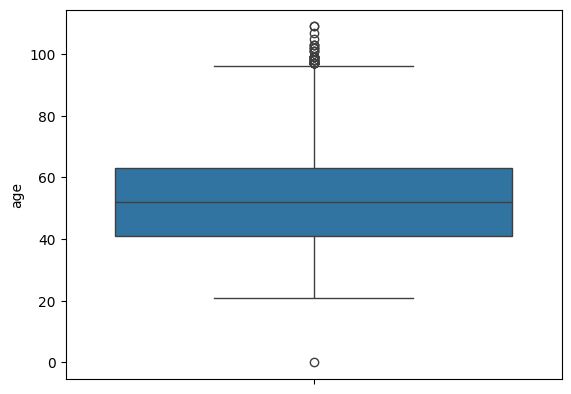

In [40]:
sns.boxplot(train['age'])

#### Dropping the tuple with age zero, and checking distribution of target variable for age > 100

In [41]:
train.drop(train[train['age'] == 0].index, inplace=True)
(train[train['age']>100]).groupby('SeriousDlqin2yrs').size()

SeriousDlqin2yrs
0    12
1     1
dtype: int64

#### There are only 13 records with 1 defaulter, dropping them as well.

In [42]:
train.drop(train[train['age'] > 100].index, inplace=True)
print(f"\033[1mTotal Records:-\033[0m\n{train.shape[0]}")

Total Records:-
149134


<Axes: ylabel='age'>

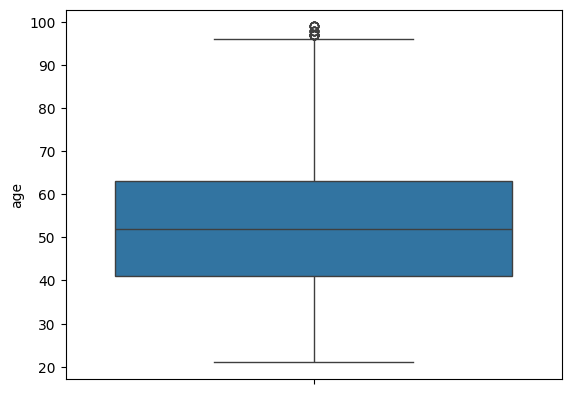

In [43]:
sns.boxplot(train['age'])

### Column 5 - DebtRatio
Monthly debt payments, alimony,living costs divided by monthy gross income
#### Possible Problems:
- Negative values (not valid).
- Sustainably, it should be less than 1.
- Very large values (e.g., >1,000 → indicates missing/zero income or data entry errors).

In [44]:
train['DebtRatio'].describe()

count    149134.000000
mean        354.088038
std        2042.333634
min           0.000000
25%           0.177338
50%           0.368182
75%           0.873975
max      329664.000000
Name: DebtRatio, dtype: float64

#### Clearly, there's no negative value and most values are less than 1, but the maximum values shows anomaly. Delving further

In [45]:
print(f"\033[1mFor Debt Ratio < 1\033[0m \n{(train[train['DebtRatio']<1]).groupby('SeriousDlqin2yrs').size()}")
print(f"\033[1mFor Debt Ratio > 1\033[0m \n{(train[train['DebtRatio']>1]).groupby('SeriousDlqin2yrs').size()}")
print(f"\033[1mFor Debt Ratio > 10\033[0m \n{(train[train['DebtRatio']>10]).groupby('SeriousDlqin2yrs').size()}")
print(f"\033[1mFor Debt Ratio > 100\033[0m \n{(train[train['DebtRatio']>100]).groupby('SeriousDlqin2yrs').size()}")
print(f"\033[1mFor Debt Ratio > 1000\033[0m \n{(train[train['DebtRatio']>1000]).groupby('SeriousDlqin2yrs').size()}")
print(f"\033[1mFor Debt Ratio > 10000\033[0m \n{(train[train['DebtRatio']>10000]).groupby('SeriousDlqin2yrs').size()}")

For Debt Ratio < 1 
SeriousDlqin2yrs
0    106163
1      7702
dtype: int64
For Debt Ratio > 1 
SeriousDlqin2yrs
0    32758
1     2286
dtype: int64
For Debt Ratio > 10 
SeriousDlqin2yrs
0    27194
1     1606
dtype: int64
For Debt Ratio > 100 
SeriousDlqin2yrs
0    22907
1     1408
dtype: int64
For Debt Ratio > 1000 
SeriousDlqin2yrs
0    16022
1      827
dtype: int64
For Debt Ratio > 10000 
SeriousDlqin2yrs
0    160
1     19
dtype: int64


These are very large number of rows for Debt Ration > 1, and hence can't be dropped. Anaysing them.
Also, Dealing with '0' monthly income records as they could possibly be the reason for exploding  Debt Ratio values

In [46]:
#Dividing data in groups of Debt Ratios to see ditribution of defaulters and '0' monthly income impact
train['bins'] = pd.cut(train['DebtRatio'], bins=50)

income_bin_check = (
    train.groupby(['bins'])                # group rows by their bin
         .apply(lambda g: pd.Series({               # g is the sub-DataFrame for that bin
             'Total_Records': len(g),               # total rows in this bin
             'Defaulters_Total': g['SeriousDlqin2yrs'].sum(), # Total defaulters in this bin (since target is 0/1, sum gives count)
             'ZeroIncome_Count': (g['MonthlyIncome'] == 0).sum(),  # boolean True counts
              # Among zero-income rows, sum the target (Defult = 0/1) to count defaulters
             'Defaulters_ZeroIncome': g.loc[g['MonthlyIncome'] == 0, 'SeriousDlqin2yrs'].sum(),
         }))
         .sort_index()  # ensure bins are in ascending numeric order
)

income_bin_check

,Total_Records,Defaulters_Total,ZeroIncome_Count,Defaulters_ZeroIncome
bins,,,,
"(-329.664, 6593.28]",148510,9940,1577,61
"(6593.28, 13186.56]",538,42,29,2
"(13186.56, 19779.84]",44,3,2,1
"(19779.84, 26373.12]",15,3,4,1
"(26373.12, 32966.4]",5,2,0,0
"(32966.4, 39559.68]",6,1,0,0
"(39559.68, 46152.96]",3,0,0,0
"(46152.96, 52746.24]",2,0,1,0
"(52746.24, 59339.52]",0,0,0,0


As can be seen from above table that '0' monthly income is not the cause of exploding Debt Ratio, and these incomes are probably legitimate record. Hence leaving the '0' monthly income as it is and doing the outlier treatment for Debt Ratio.

In [47]:
#Capping at 99 perentile
cap_value = train['DebtRatio'].quantile(0.99)

# Apply capping
train['DebtRatio_capped'] = np.where(train['DebtRatio'] > cap_value, cap_value, train['DebtRatio'])

print(f"Capped DebtRatio at 99th percentile: {cap_value}")
print(train['DebtRatio_capped'].describe())

Capped DebtRatio at 99th percentile: 4984.0
count    149134.000000
mean        317.596789
std         908.413698
min           0.000000
25%           0.177338
50%           0.368182
75%           0.873975
max        4984.000000
Name: DebtRatio_capped, dtype: float64


In [48]:
#Log transformation to reduce skewness
# Log(1 + x) transform works best for long-tailed distributions
train['DebtRatio_transformed'] = np.log1p(train['DebtRatio_capped'])

print(train['DebtRatio_transformed'].describe())

count    149134.000000
mean          1.526720
std           2.620110
min           0.000000
25%           0.163256
50%           0.313483
75%           0.628062
max           8.514189
Name: DebtRatio_transformed, dtype: float64


In [49]:
train.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,age,DebtRatio,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,MonthlyIncome,NumberOfDependents,bins,DebtRatio_capped,DebtRatio_transformed
2,1,0.036942,41,29,43,0.719174,0,0,0,23084.0,0.0,"(-329.664, 6593.28]",0.719174,0.541844
3,0,0.635363,33,26,61,0.429449,6,0,1,23084.0,1.0,"(-329.664, 6593.28]",0.429449,0.357289
4,0,0.297748,42,25,44,1.237481,0,0,0,12400.0,2.0,"(-329.664, 6593.28]",1.237481,0.805351
5,1,0.507886,33,25,44,0.467231,1,0,0,23084.0,0.0,"(-329.664, 6593.28]",0.467231,0.383377
6,0,0.985390,42,25,51,0.515205,1,0,0,23084.0,1.0,"(-329.664, 6593.28]",0.515205,0.415551


In [50]:
# Dropping bins column
train.drop(columns=['bins'], inplace = True)

### Columns
- **6 - NumberOfTime30-59DaysPastDueNotWorse**
- **7 - NumberOfTime60-89DaysPastDueNotWorse**
- **8 - NumberOfTimes90DaysLate<br>**

Number of times borrower has been 30-59 days, 60-89 days, or 90+days past due in the last 2 years.
#### Possible Problems:
- Negative values (not valid).
- Extremely large values

In [51]:
train.groupby(['NumberOfTime30-59DaysPastDueNotWorse']).size()

NumberOfTime30-59DaysPastDueNotWorse
0     125225
1      16019
2       4587
3       1750
4        747
5        342
6        140
7         54
8         25
9         12
10         4
11         1
12         2
13         1
96         5
98       220
dtype: int64

In [52]:
train.groupby(['NumberOfTime60-89DaysPastDueNotWorse']).size()

NumberOfTime60-89DaysPastDueNotWorse
0     141585
1       5723
2       1117
3        318
4        104
5         34
6         16
7          8
8          2
9          1
11         1
96         5
98       220
dtype: int64

In [53]:
train.groupby(['NumberOfTimes90DaysLate']).size()

NumberOfTimes90DaysLate
0     140859
1       5227
2       1554
3        666
4        291
5        131
6         80
7         38
8         20
9         19
10         8
11         5
12         2
13         4
14         2
15         2
17         1
96         5
98       220
dtype: int64

#### Clearly there's some problem with frequency of late payments showing 96 and 98 day delay. Hence instead simply deleting them, first checking their impact on actual default.

In [54]:
print(train[train['NumberOfTimes90DaysLate']>=96].groupby(['SeriousDlqin2yrs']).size())
print(train[train['NumberOfTime60-89DaysPastDueNotWorse']>=96].groupby(['SeriousDlqin2yrs']).size())
print(train[train['NumberOfTime30-59DaysPastDueNotWorse']>=96].groupby(['SeriousDlqin2yrs']).size())

SeriousDlqin2yrs
0     89
1    136
dtype: int64
SeriousDlqin2yrs
0     89
1    136
dtype: int64
SeriousDlqin2yrs
0     89
1    136
dtype: int64


Here we can see there are multiple defaulters for these rows, hence keeing them as it is for now and moving on to combine these 3 columns as they represent same type of data and capping (clipping) them at '10' delinquencies, so that no rows are lost and large values dont't overwhelm the model.

In [55]:
#Delinquency aggregation and capping
delin_cols = ['NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse','NumberOfTimes90DaysLate']
for c in delin_cols:
    train[c] = train[c].clip(lower=0, upper=10)
train['TotalDelinquencies'] = train[delin_cols].sum(axis=1)

In [56]:
train['TotalDelinquencies'].value_counts()

TotalDelinquencies
0     118863
1      17211
2       5935
3       2882
4       1592
5        940
6        591
7        380
30       225
8        196
9        125
10        77
11        56
12        23
13        14
14        12
15         6
19         2
16         2
17         2
Name: count, dtype: int64

## Raw EDA

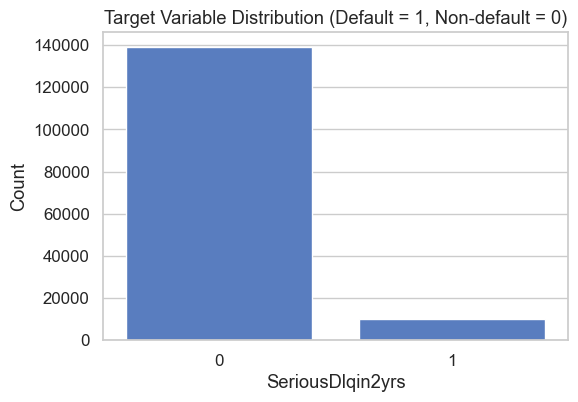

Default rate in dataset: 6.70%


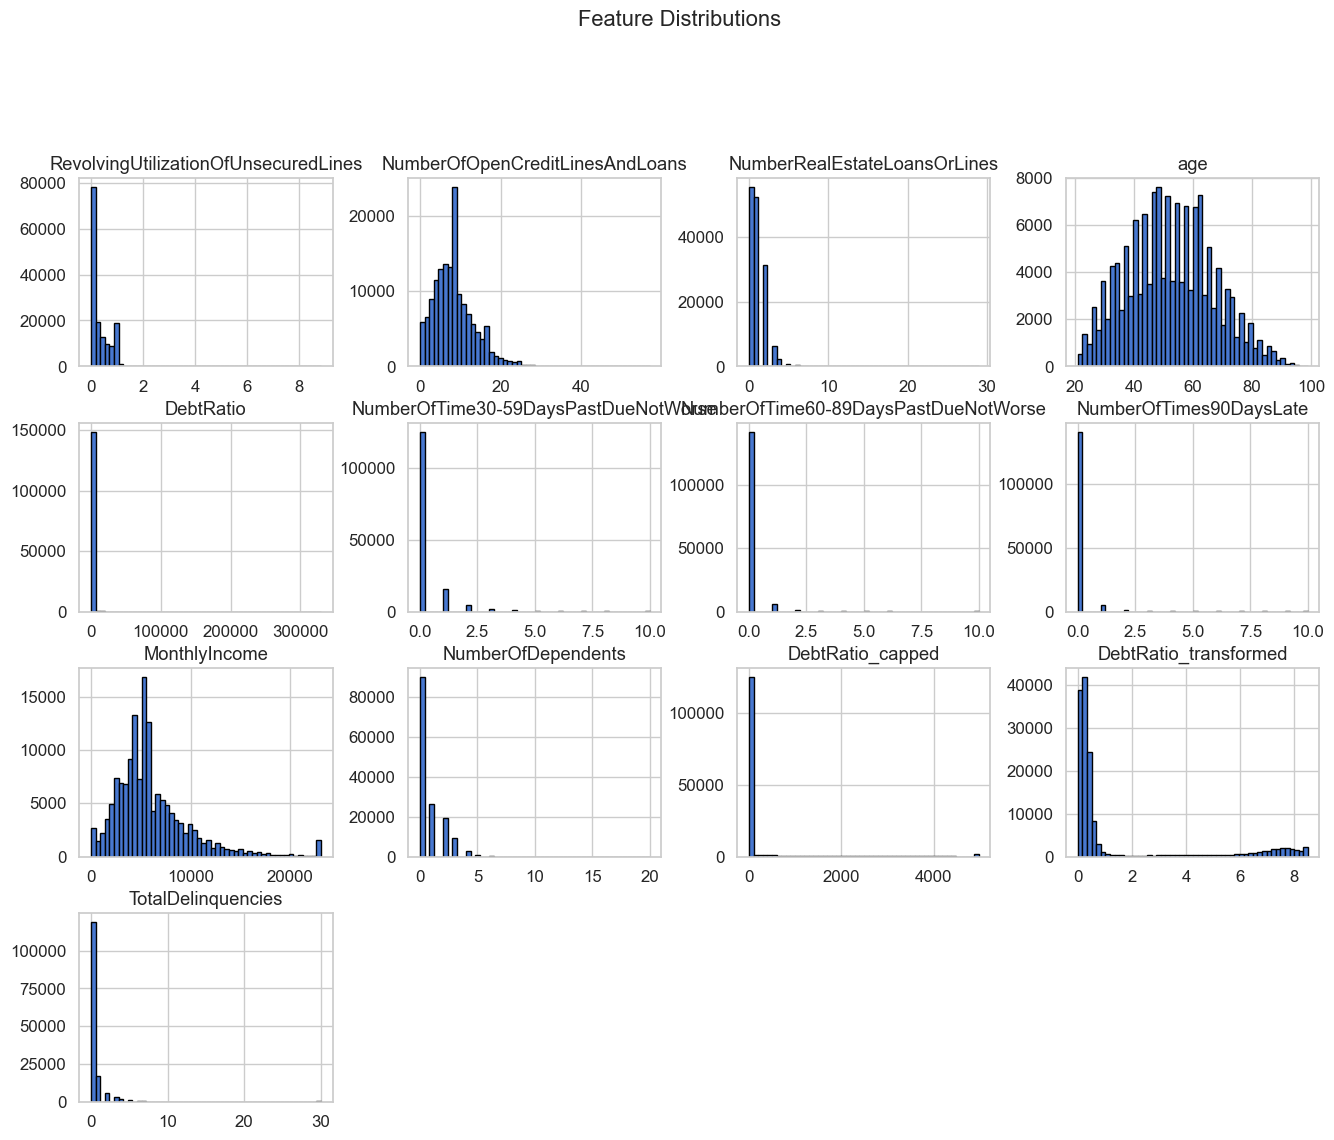

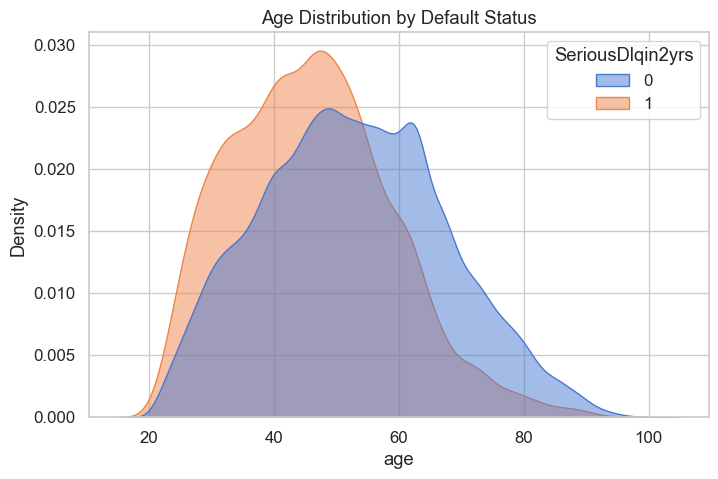

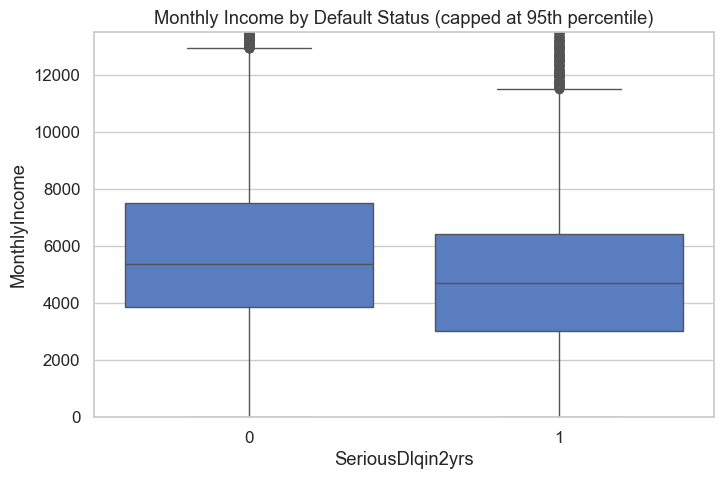

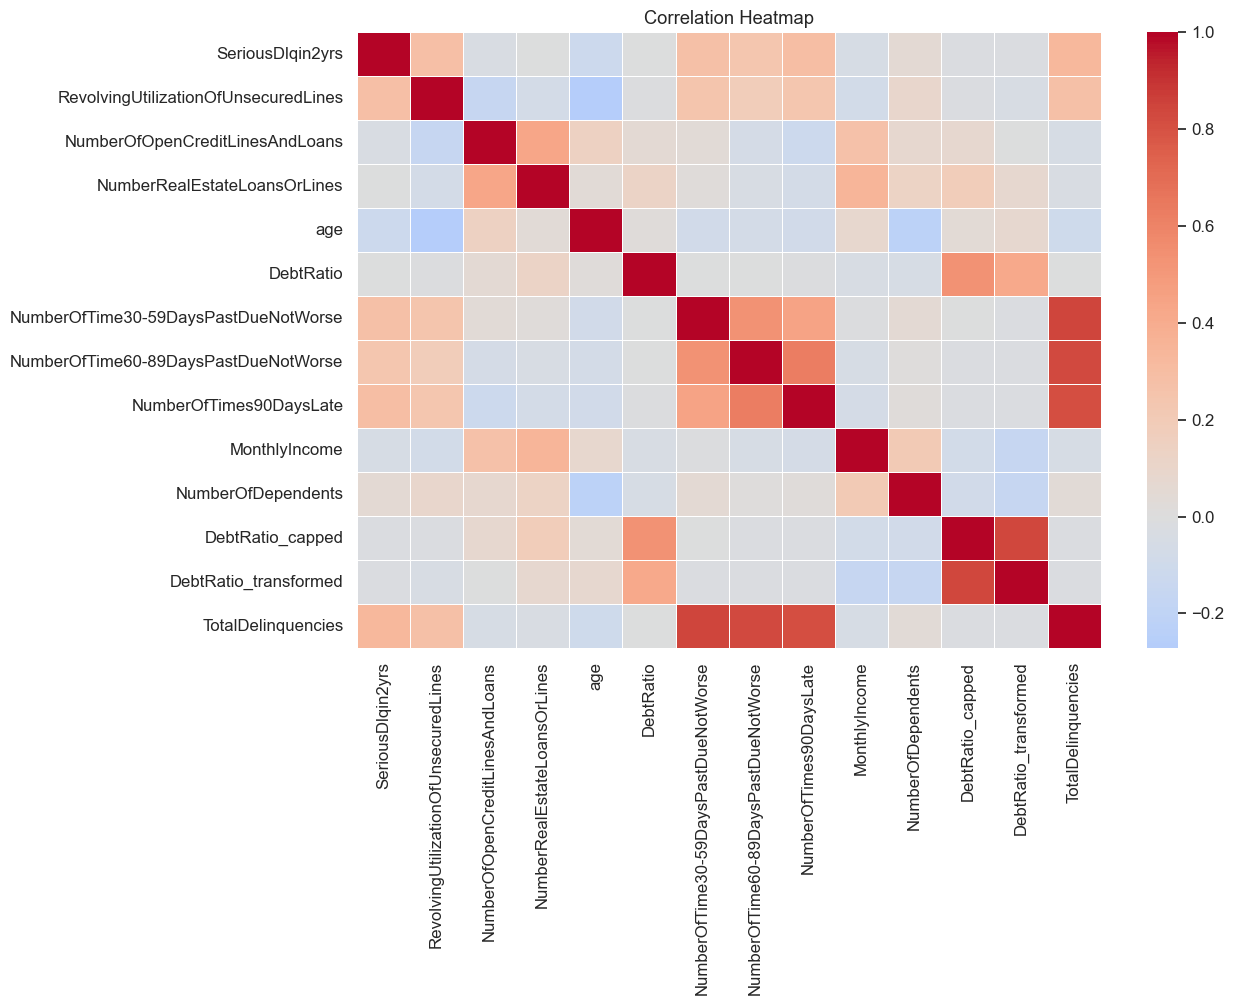

In [57]:
# Setting plot look
sns.set(style="whitegrid", palette="muted", font_scale=1.1)

# 1. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='SeriousDlqin2yrs', data=train)
plt.title("Target Variable Distribution (Default = 1, Non-default = 0)")
plt.xlabel("SeriousDlqin2yrs")
plt.ylabel("Count")
plt.show()

# Checking imbalance ratio
default_rate = train['SeriousDlqin2yrs'].mean()
print(f"Default rate in dataset: {default_rate:.2%}")

# 2. Univariate Analysis (Histograms)
numeric_cols = train.drop(columns=['SeriousDlqin2yrs']).columns
train[numeric_cols].hist(figsize=(16,12), bins=50, edgecolor='black')
plt.suptitle("Feature Distributions", y=1.02)
plt.show()

# 3. Bivariate Analysis (Feature vs Target)
# Distribution of Age split by Default
plt.figure(figsize=(8,5))
sns.kdeplot(data=train, x="age", hue="SeriousDlqin2yrs", common_norm=False, fill=True, alpha=0.5)
plt.title("Age Distribution by Default Status")
plt.show()
#Boxplot for Monthly Income by Default
plt.figure(figsize=(8,5))
sns.boxplot(x="SeriousDlqin2yrs", y="MonthlyIncome", data=train)
plt.ylim(0, train['MonthlyIncome'].quantile(0.95))  # zoom in (ignore extreme outliers)
plt.title("Monthly Income by Default Status (capped at 95th percentile)")
plt.show()

# 4. Correlation Analysis
plt.figure(figsize=(12,8))
corr = train.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

The raw EDA tells us that-
- The target variable is highly imbalanced.
- Features are highly skewed, but there's nothing to do much there as the distribution of features is in respective logical ranges, except for the Debt Ratio which has been taken care of by capping and log-transform earlier. The transformed column will be used for linear model and original column for tree based models.
- No single variable is excessively responsible for default (SeriousDlqin2yrs = 1).
#### The main problem at hand is now handling class imbalance of target variable as:
- Imbalance → model learns majority class bias.
- Accuracy becomes misleading. If we ignore it, models will just predict “non-default” for everyone and still look “accurate.”

We need strategies that either rebalance the data or change the learning objective.

### Resampling and choice of XGBoost over Logistic Regression for Imbalanced Credit Risk Data

Resampling strategies (undersampling, oversampling, SMOTE) can help but either discard valuable data, risk overfitting, or generate unrealistic synthetic samples.  

Logistic Regression with `class_weight='balanced'` helps handle imbalance, but it is a **linear model** that struggles with non-linear interactions (e.g., age × income × delinquencies). It also tends to underfit when features have complex relationships.  

XGBoost, on the other hand, can directly handle imbalance using `scale_pos_weight`, capture **non-linearities and feature interactions** automatically, and is more robust to outliers and skewed distributions. It also provides built-in regularization and early stopping, which improve generalization.  
Thus, while Logistic Regression is a simple baseline, **XGBoost consistently delivers better discrimination (higher ROC-AUC / PR-AUC) in credit risk tasks** without needing heavy resampling.

### Model Preparation

In [58]:
#feature matrix and label
features = [
    'RevolvingUtilizationOfUnsecuredLines', 'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines','age','DebtRatio_transformed','MonthlyIncome',
    'NumberOfDependents','NumberOfTime30-59DaysPastDueNotWorse','NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate','TotalDelinquencies',
]
X = train[features].copy()
y = train['SeriousDlqin2yrs'].copy()
X.head()

,RevolvingUtilizationOfUnsecuredLines,NumberOfOpenCreditLinesAndLoans,NumberRealEstateLoansOrLines,age,DebtRatio_transformed,MonthlyIncome,NumberOfDependents,NumberOfTime30-59DaysPastDueNotWorse,NumberOfTime60-89DaysPastDueNotWorse,NumberOfTimes90DaysLate,TotalDelinquencies
2,0.036942,41,29,43,0.541844,23084.0,0.0,0,0,0,0
3,0.635363,33,26,61,0.357289,23084.0,1.0,6,0,1,7
4,0.297748,42,25,44,0.805351,12400.0,2.0,0,0,0,0
5,0.507886,33,25,44,0.383377,23084.0,0.0,1,0,0,1
6,0.985390,42,25,51,0.415551,23084.0,1.0,1,0,0,1


In [59]:
#Train/validation/test split (stratified)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=RANDOM_SEED)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_SEED)
print('Train/Val/Test sizes:', X_train.shape[0], X_val.shape[0], X_test.shape[0])

Train/Val/Test sizes: 119307 14913 14914


In [60]:
#Scaling for logistic regression(fit scaler on train only)
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()
num_to_scale = ['RevolvingUtilizationOfUnsecuredLines','DebtRatio_transformed','MonthlyIncome','age']
scaler.fit(X_train[num_to_scale])
X_train_scaled[num_to_scale] = scaler.transform(X_train[num_to_scale])
X_val_scaled[num_to_scale] = scaler.transform(X_val[num_to_scale])
X_test_scaled[num_to_scale] = scaler.transform(X_test[num_to_scale])

In [61]:
#Computing class imbalance ratio for XGBoost Classifier
neg, pos = y_train.value_counts()[0], y_train.value_counts()[1]
scale_pos_weight = neg / pos
print(f"scale_pos_weight for XGBoost: {scale_pos_weight:.2f}")

scale_pos_weight for XGBoost: 13.93


### Models

Logistic ROC-AUC: 0.8414560168908309
Logistic PR-AUC: 0.3377232923483317

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      0.81      0.88     13914
           1       0.21      0.72      0.33       999

    accuracy                           0.80     14913
   macro avg       0.59      0.76      0.60     14913
weighted avg       0.92      0.80      0.85     14913


Confusion matrix:
[[11230  2684]
 [  282   717]]


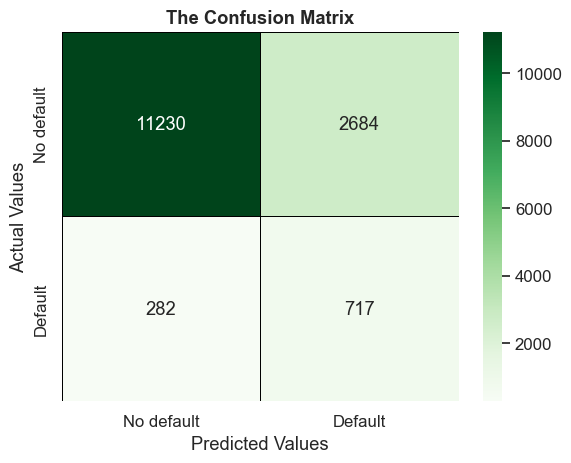

In [62]:
#Baseline: Logistic Regression

log_clf = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=RANDOM_SEED)
log_clf.fit(X_train_scaled, y_train)

pred_log = log_clf.predict(X_val_scaled)
proba_log = log_clf.predict_proba(X_val_scaled)[:,1]

print('Logistic ROC-AUC:', roc_auc_score(y_val, proba_log))
print('Logistic PR-AUC:', average_precision_score(y_val, proba_log))

print("\nClassification report (threshold=0.5):")
print(classification_report(y_val, pred_log))

print("\nConfusion matrix:")
cm_log = confusion_matrix(y_val, pred_log)
print(cm_log)
sns.heatmap(cm_log,annot=True,fmt='d',cmap='Greens',linewidths=0.5,linecolor='Black')
plt.xticks(np.arange(2)+.5,['No default','Default'])
plt.yticks(np.arange(2)+.5,['No default','Default'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("The Confusion Matrix", fontweight='bold')
plt.show()

[0]	validation_0-aucpr:0.31363	validation_0-auc:0.81347
[20]	validation_0-aucpr:0.36153	validation_0-auc:0.84842
[40]	validation_0-aucpr:0.36714	validation_0-auc:0.84952
[60]	validation_0-aucpr:0.36860	validation_0-auc:0.85050
[80]	validation_0-aucpr:0.37011	validation_0-auc:0.85109
[100]	validation_0-aucpr:0.36940	validation_0-auc:0.85134
[120]	validation_0-aucpr:0.37064	validation_0-auc:0.85156
[140]	validation_0-aucpr:0.37037	validation_0-auc:0.85164
[160]	validation_0-aucpr:0.36826	validation_0-auc:0.85143
[180]	validation_0-aucpr:0.36830	validation_0-auc:0.85146
[185]	validation_0-aucpr:0.36812	validation_0-auc:0.85147
XGB ROC-AUC: 0.8518142261853632
XGB PR-AUC: 0.37054998686213386

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     13914
           1       0.22      0.76      0.34       999

    accuracy                           0.80     14913
   macro avg       0.60      0.78      0.61   

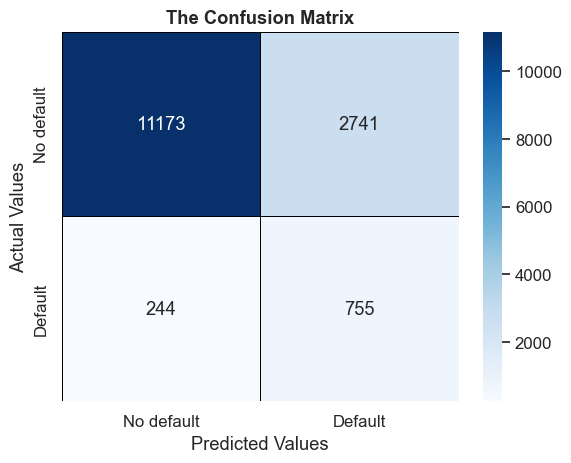

In [63]:
#XGBoost: tuned starting configuration with early stopping
xgb_model = xgb.XGBClassifier(
    scale_pos_weight=scale_pos_weight,  # important: weight positive class proportional to imbalance
    learning_rate=0.05,             # eta: lower than default (0.3). 0.05 balances speed & generalization.
                                    # Lower eta -> safer generalization, but requires more trees.
    n_estimators=1000,              # allow many trees but rely on early stopping to pick the effective number
    early_stopping_rounds=50,       # stop if no improvement in 50 rounds
    max_depth=5,                    # moderate depth: captures interactions but limits overfitting (3-8 typical)
    min_child_weight=3,             # prevents small, noisy splits
    subsample=0.8,                  # row subsampling per tree (0.6-1.0). 0.8 adds robustness, reduces overfitting.
    colsample_bytree=0.8,           # feature subsampling per tree (0.5-1.0). 0.8 is a good default.
    reg_lambda=1.0,                 # L2 regularization (default ~1). Increase if still overfitting.
    reg_alpha=0.5,                  # L1 regularization; small positive to encourage sparsity if many weak features
    eval_metric=['aucpr', 'auc'],   # monitor AUC-PR (important for rare events) and AUC
    random_state=RANDOM_SEED,
    n_jobs=-1
)

xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=20                  # prints progress every 20 rounds (set 0 to silence)
)

pred_xgb = xgb_model.predict(X_val)
proba_xgb = xgb_model.predict_proba(X_val)[:,1]

print('XGB ROC-AUC:', roc_auc_score(y_val, proba_xgb))
print('XGB PR-AUC:', average_precision_score(y_val, proba_xgb))

print("\nClassification report (threshold=0.5):")
print(classification_report(y_val, pred_xgb))

print("\nConfusion matrix:")
cm_xgb = confusion_matrix(y_val, pred_xgb)
print(cm_xgb)
sns.heatmap(cm_xgb,annot=True,fmt='d',cmap='Blues',linewidths=0.5,linecolor='Black')
plt.xticks(np.arange(2)+.5,['No default','Default'])
plt.yticks(np.arange(2)+.5,['No default','Default'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("The Confusion Matrix", fontweight='bold')
plt.show()

#### Clearly XGBoost performs better on ROC-AUC and also better predicts the actual defaulters, hence final evaluation of test data using XGBoost model.

Test ROC-AUC: 0.8648227458504139
Test PR-AUC: 0.40312421790552383

Classification report (threshold=0.5):
              precision    recall  f1-score   support

           0       0.98      0.80      0.88     13915
           1       0.22      0.75      0.34       999

    accuracy                           0.80     14914
   macro avg       0.60      0.78      0.61     14914
weighted avg       0.93      0.80      0.85     14914


Confusion matrix:
[[11179  2736]
 [  245   754]]


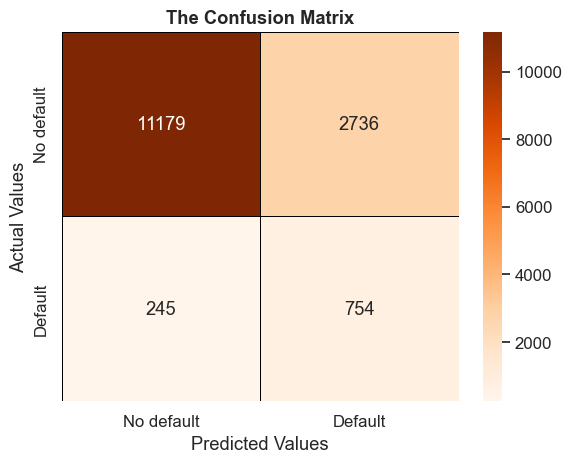

In [64]:
#Evaluation on test set
pred_xgb_test = xgb_model.predict(X_test)
proba_xgb_test = xgb_model.predict_proba(X_test)[:,1]

print('Test ROC-AUC:', roc_auc_score(y_test, proba_xgb_test))
print('Test PR-AUC:', average_precision_score(y_test, proba_xgb_test))

print("\nClassification report (threshold=0.5):")
print(classification_report(y_test, pred_xgb_test))

print("\nConfusion matrix:")
cm_xgb_test = confusion_matrix(y_test, pred_xgb_test)
print(cm_xgb_test)
sns.heatmap(cm_xgb_test,annot=True,fmt='d',cmap='Oranges',linewidths=0.5,linecolor='Black')
plt.xticks(np.arange(2)+.5,['No default','Default'])
plt.yticks(np.arange(2)+.5,['No default','Default'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("The Confusion Matrix", fontweight='bold')
plt.show()

### Substitue for default 0.5 threshold for credit risk
#### Why 0.5 is a bad threshold?
- The model outputs probabilities of default.
- With imbalanced data (say 7% defaults), very few samples are >0.5 probability.
- At 0.5 threshold, you’ll predict “all non-default” most of the time → high accuracy but terrible recall for defaulters.

#### Threshold can be based on business objective
- "Don’t reject too many good customers"
- "Better safe than sorry"

#### Objective 1: Don’t reject too many good customers
- Few good customers are wrongly rejected (low False Positives).
- But you miss more defaulters (higher False Negatives).
- Good if you want to preserve business volume and not over-reject.
- It'll be achieved through higher precision.


High Precision threshold (precision ≥ 50%): 0.869
Classification Report (High Precision):
               precision    recall  f1-score   support

           0      0.954     0.975     0.964     13915
           1      0.500     0.351     0.413       999

    accuracy                          0.933     14914
   macro avg      0.727     0.663     0.689     14914
weighted avg      0.924     0.933     0.928     14914

Confusion Matrix (High Precision):
 [[13564   351]
 [  648   351]]


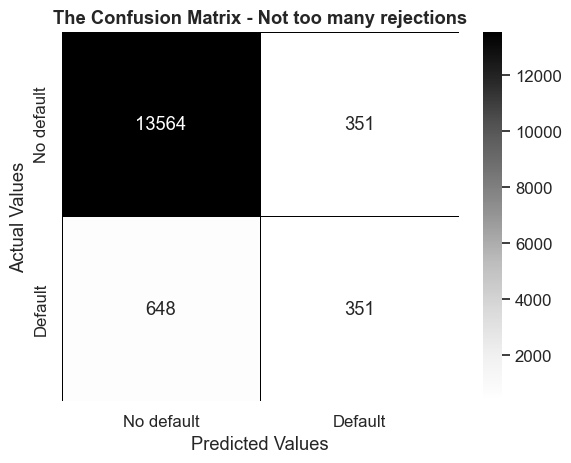

In [65]:
# Get probabilities from your trained model
y_test_proba = xgb_model.predict_proba(X_test)[:,1]

# Precision-Recall curve
prec, rec, thr = precision_recall_curve(y_test, y_test_proba)

# Pick highest threshold that achieves at least 50% precision
precision_target = 0.50
prec_idx = np.where(prec >= precision_target)[0][0]   # first index where precision >= target
high_prec_thr = thr[prec_idx]

print(f"\nHigh Precision threshold (precision ≥ {precision_target:.0%}): {high_prec_thr:.3f}")
y_test_pred_prec = (y_test_proba >= high_prec_thr).astype(int)


print("Classification Report (High Precision):\n", classification_report(y_test, y_test_pred_prec, digits=3))
print("Confusion Matrix (High Precision):\n", confusion_matrix(y_test, y_test_pred_prec))
sns.heatmap(confusion_matrix(y_test, y_test_pred_prec),annot=True,fmt='d',cmap='Greys',linewidths=0.5,linecolor='Black')
plt.xticks(np.arange(2)+.5,['No default','Default'])
plt.yticks(np.arange(2)+.5,['No default','Default'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("The Confusion Matrix - Not too many rejections", fontweight='bold')
plt.show()

#### Objective 2: Better safe than sorry
- Most defaulters are caught (low False Negatives).
- But many good customers get wrongly flagged → more False Positives.
- Good if the cost of a missed default is very high.
- It'll be achieved through high recall.


High Recall threshold (recall ≥ 80%): 0.439
Classification Report (High Recall):
               precision    recall  f1-score   support

           0      0.982     0.761     0.857     13915
           1      0.194     0.801     0.312       999

    accuracy                          0.764     14914
   macro avg      0.588     0.781     0.585     14914
weighted avg      0.929     0.764     0.821     14914

Confusion Matrix (High Recall):
 [[10590  3325]
 [  199   800]]


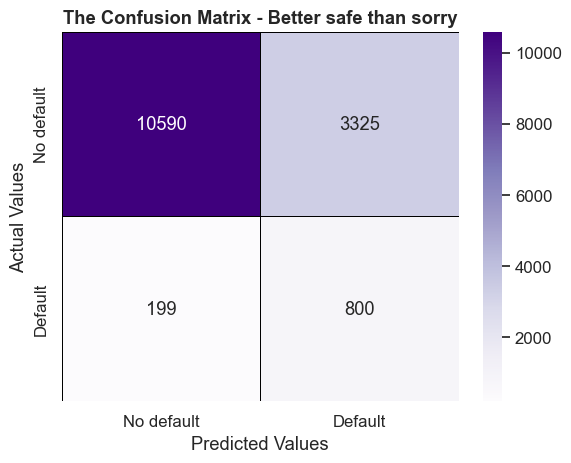

In [66]:
# Get probabilities from your trained model
y_test_proba = xgb_model.predict_proba(X_test)[:,1]

# Precision-Recall curve
prec, rec, thr = precision_recall_curve(y_test, y_test_proba)

# Pick lowest threshold that achieves at least 80% recall
recall_target = 0.80
recall_idx = np.where(rec >= recall_target)[0][-1]   # last index where recall >= target
high_recall_thr = thr[recall_idx]

print(f"\nHigh Recall threshold (recall ≥ {recall_target:.0%}): {high_recall_thr:.3f}")
y_test_pred_recall = (y_test_proba >= high_recall_thr).astype(int)

print("Classification Report (High Recall):\n", classification_report(y_test, y_test_pred_recall, digits=3))
print("Confusion Matrix (High Recall):\n", confusion_matrix(y_test, y_test_pred_recall))
sns.heatmap(confusion_matrix(y_test, y_test_pred_recall),annot=True,fmt='d',cmap='Purples',linewidths=0.5,linecolor='Black')
plt.xticks(np.arange(2)+.5,['No default','Default'])
plt.yticks(np.arange(2)+.5,['No default','Default'])
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")
plt.title("The Confusion Matrix - Better safe than sorry", fontweight='bold')
plt.show()